# Structural and Functional Network Overlap

Explore overlap between strong structural connections and positive or negative functional connections using group-average networks.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


In [1]:
from pathlib import Path
figure_dir = Path("figures/structural_functional_overlap")
figure_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D


def load_connectome(path):
    comments = []
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                comments.append(line.strip())
            else:
                break

    names = None
    for c in comments:
        if c.lower().startswith("# name:"):
            names = [x.strip() for x in c.split(":", 1)[1].split(",")]

    df = pd.read_csv(path, header=None, comment="#")

    if names is not None and len(names) == df.shape[0]:
        df.index = names
        df.columns = names

    return df


def build_edge_table(S, F):
    mask = np.triu(np.ones(S.shape, dtype=bool), 1)
    rows, cols = np.where(mask)

    edges = pd.DataFrame({
        "i": [S.index[r] for r in rows],
        "j": [S.columns[c] for c in cols],
        "s": S.values[mask],
        "f": F.values[mask],
    })

    return edges


def select_top_k_sets(edges, k_struct=15, k_func_pos=15, k_func_neg=15):
    # top structural edges
    top_struct = edges[edges["s"] > 0].nlargest(k_struct, "s").copy()
    top_struct["in_struct"] = True

    # top positive functional edges
    top_func_pos = edges[edges["f"] > 0].nlargest(k_func_pos, "f").copy()
    top_func_pos["in_func_pos"] = True

    # top negative functional edges
    # most negative = smallest f
    top_func_neg = edges[edges["f"] < 0].nsmallest(k_func_neg, "f").copy()
    top_func_neg["in_func_neg"] = True

    return top_struct, top_func_pos, top_func_neg


def combine_edge_sets(edges, top_struct, top_func_pos, top_func_neg):
    combined = edges.copy()

    struct_keys = set(zip(top_struct["i"], top_struct["j"]))
    pos_keys = set(zip(top_func_pos["i"], top_func_pos["j"]))
    neg_keys = set(zip(top_func_neg["i"], top_func_neg["j"]))

    combined["in_struct"] = [
        (i, j) in struct_keys for i, j in zip(combined["i"], combined["j"])
    ]
    combined["in_func_pos"] = [
        (i, j) in pos_keys for i, j in zip(combined["i"], combined["j"])
    ]
    combined["in_func_neg"] = [
        (i, j) in neg_keys for i, j in zip(combined["i"], combined["j"])
    ]

    subset = combined[
        combined["in_struct"] | combined["in_func_pos"] | combined["in_func_neg"]
    ].copy()

    def label(row):
        if row["in_struct"] and row["in_func_pos"]:
            return "struct_and_func_pos"
        if row["in_struct"] and row["in_func_neg"]:
            return "struct_and_func_neg"
        if row["in_struct"]:
            return "struct_only"
        if row["in_func_pos"]:
            return "func_pos_only"
        if row["in_func_neg"]:
            return "func_neg_only"
        return "other"

    subset["category"] = subset.apply(label, axis=1)

    return subset


def build_circular_layout(nodes):
    nodes = list(nodes)
    angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
    return {node: (math.cos(a), math.sin(a)) for node, a in zip(nodes, angles)}


def short_label(name):
    hemi = ""
    if name.endswith("_left"):
        hemi = "L"
    elif name.endswith("_right"):
        hemi = "R"

    stem = name.replace("_left", "").replace("_right", "")
    parts = [p for p in stem.split("_") if p not in {"gyrus", "cortex"}]
    text = " ".join(parts[:3])

    if hemi:
        text += f" ({hemi})"
    return text


def plot_edges(
    df,
    pos,
    title,
    mode="category",
    save_path=None
):
    color_map = {
        "struct_only": "red",
        "func_pos_only": "blue",
        "func_neg_only": "deepskyblue",
        "struct_and_func_pos": "purple",
        "struct_and_func_neg": "orange",
    }

    linestyle_map = {
        "struct_only": "-",
        "func_pos_only": "-",
        "func_neg_only": "--",
        "struct_and_func_pos": "-",
        "struct_and_func_neg": "--",
    }
    
    legend_labels = {
        "struct_only": "Structural Only",
        "func_pos_only": "Functional (Positive) Only",
        "func_neg_only": "Functional (Negative) Only",
        "struct_and_func_pos": "Structural & Functional (Positive)",
        "struct_and_func_neg": "Structural & Functional (Negative)",
    }

    nodes = list(pos.keys())
    degree = {n: 0 for n in nodes}
    for _, row in df.iterrows():
        degree[row["i"]] += 1
        degree[row["j"]] += 1

    fig, ax = plt.subplots(figsize=(11, 11))

    for _, row in df.iterrows():
        x1, y1 = pos[row["i"]]
        x2, y2 = pos[row["j"]]

        if mode == "category":
            color = color_map[row["category"]]
            linestyle = linestyle_map[row["category"]]
        elif mode == "struct":
            color = "red"
            linestyle = "-"
        elif mode == "func_pos":
            color = "blue"
            linestyle = "-"
        elif mode == "func_neg":
            color = "deepskyblue"
            linestyle = "--"

        ax.plot([x1, x2], [y1, y2], color=color, linestyle=linestyle, linewidth=3, alpha=0.8)

    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    sizes = [120 + 40 * degree[n] for n in nodes]

    ax.scatter(xs, ys, s=sizes, color="lightgray", edgecolor="black", linewidth=0.8, zorder=2)

    for n in nodes:
        x, y = pos[n]
        ax.text(1.10 * x, 1.10 * y, short_label(n), ha="center", va="center", fontsize=8)

    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

    if mode == "category":
        legend_handles = []
        for category in sorted(df['category'].unique()):
            if category in color_map:
                handle = Line2D([0], [0], 
                                color=color_map[category], 
                                linestyle=linestyle_map[category], 
                                lw=1, 
                                label=legend_labels.get(category, category))
                legend_handles.append(handle)
        
        if legend_handles:
            ax.legend(handles=legend_handles, loc='lower right', fontsize=10)

    if save_path:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()


In [2]:
base_path = "data/connectomes/"

patient_connectomes_S = []
patient_connectomes_F = []
for patient_id in range(32, 51):
    patient_connectomes_S.append(load_connectome(base_path + f"{patient_id}_WFA_68.csv"))
    patient_connectomes_F.append(load_connectome(base_path + f"{patient_id}_rsfMRI_68.csv"))


# S and F = average connectomes across patients
S = sum(patient_connectomes_S) / len(patient_connectomes_S)
F = sum(patient_connectomes_F) / len(patient_connectomes_F)



edges = build_edge_table(S, F)

top_struct, top_func_pos, top_func_neg = select_top_k_sets(
    edges,
    k_struct=150,
    k_func_pos=150,
    k_func_neg=150
)

selected = combine_edge_sets(edges, top_struct, top_func_pos, top_func_neg)

presentation_nodes = sorted(set(selected["i"]).union(set(selected["j"])))
shared_pos = build_circular_layout(presentation_nodes)

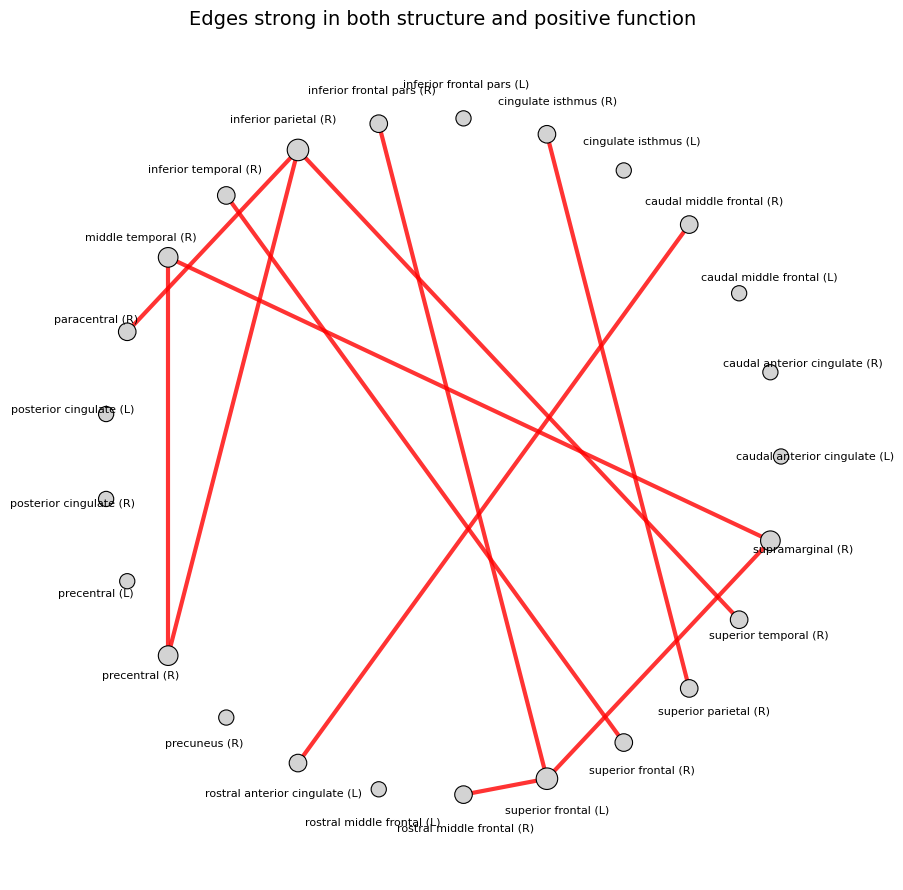

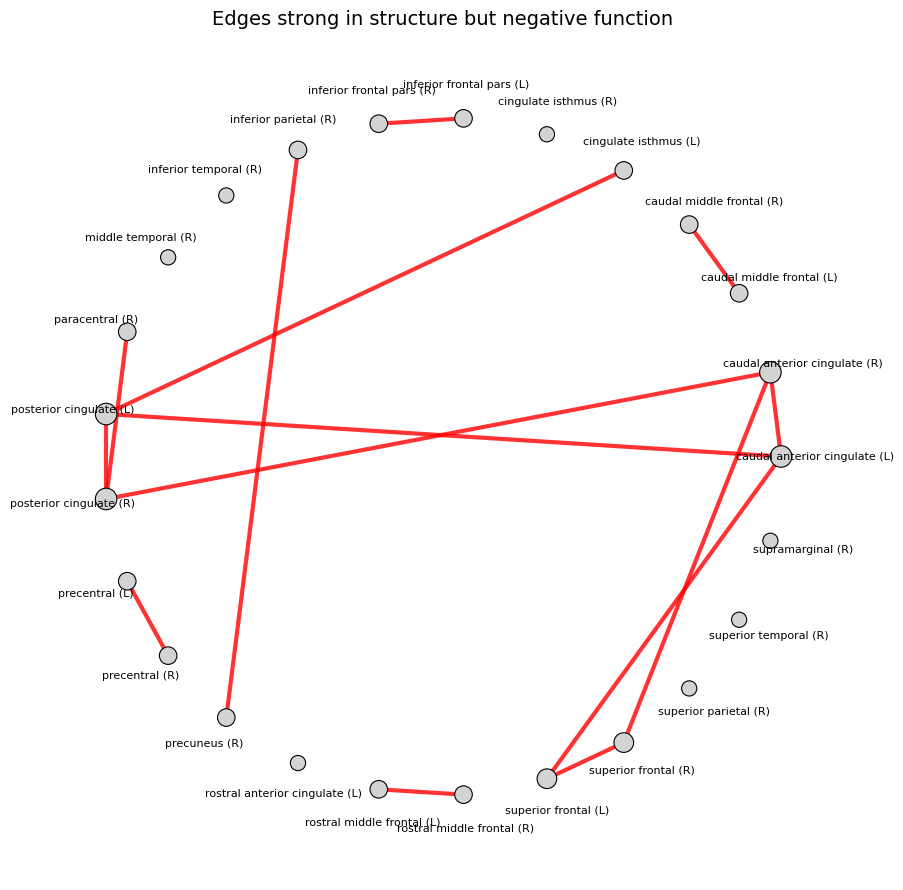

In [3]:
struct_edges = set(zip(top_struct.i, top_struct.j))
pos_edges = set(zip(top_func_pos.i, top_func_pos.j))
neg_edges = set(zip(top_func_neg.i, top_func_neg.j))

sf_pos = struct_edges & pos_edges
sf_neg = struct_edges & neg_edges
sf_pos_df = edges[
    edges.apply(lambda r: (r.i, r.j) in sf_pos, axis=1)
]

sf_neg_df = edges[
    edges.apply(lambda r: (r.i, r.j) in sf_neg, axis=1)
]
intersection_nodes = sorted(
    set(sf_pos_df.i).union(sf_pos_df.j)
    .union(sf_neg_df.i).union(sf_neg_df.j)
)
intersection_pos = build_circular_layout(intersection_nodes)


def plot_edges_intersection(df, pos, title, mode="struct", save_path=None):
    color_map = {
        "struct": "red",
        "func_pos": "blue",
        "func_neg": "deepskyblue",
        "struct_and_func_pos": "purple",
        "struct_and_func_neg": "orange",
    }

    linestyle_map = {
        "struct": "-",
        "func_pos": "-",
        "func_neg": "--",
        "struct_and_func_pos": "-",
        "struct_and_func_neg": "--",
    }

    nodes = list(pos.keys())
    degree = {n: 0 for n in nodes}
    for _, row in df.iterrows():
        degree[row["i"]] += 1
        degree[row["j"]] += 1

    fig, ax = plt.subplots(figsize=(11, 11))

    for _, row in df.iterrows():
        x1, y1 = pos[row["i"]]
        x2, y2 = pos[row["j"]]

        ax.plot(
            [x1, x2], [y1, y2],
            color=color_map[mode],
            linestyle=linestyle_map[mode],
            linewidth=3,
            alpha=0.8
        )

    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    sizes = [120 + 40 * degree[n] for n in nodes]

    ax.scatter(xs, ys, s=sizes, color="lightgray", edgecolor="black", linewidth=0.8, zorder=2)

    for n in nodes:
        x, y = pos[n]
        ax.text(1.10 * x, 1.10 * y, short_label(n), ha="center", va="center", fontsize=8)

    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

    if save_path:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")

    plt.show()


plot_edges_intersection(sf_pos_df, intersection_pos,
           title="Edges strong in both structure and positive function")

plot_edges_intersection(sf_neg_df, intersection_pos,
           title="Edges strong in structure but negative function")

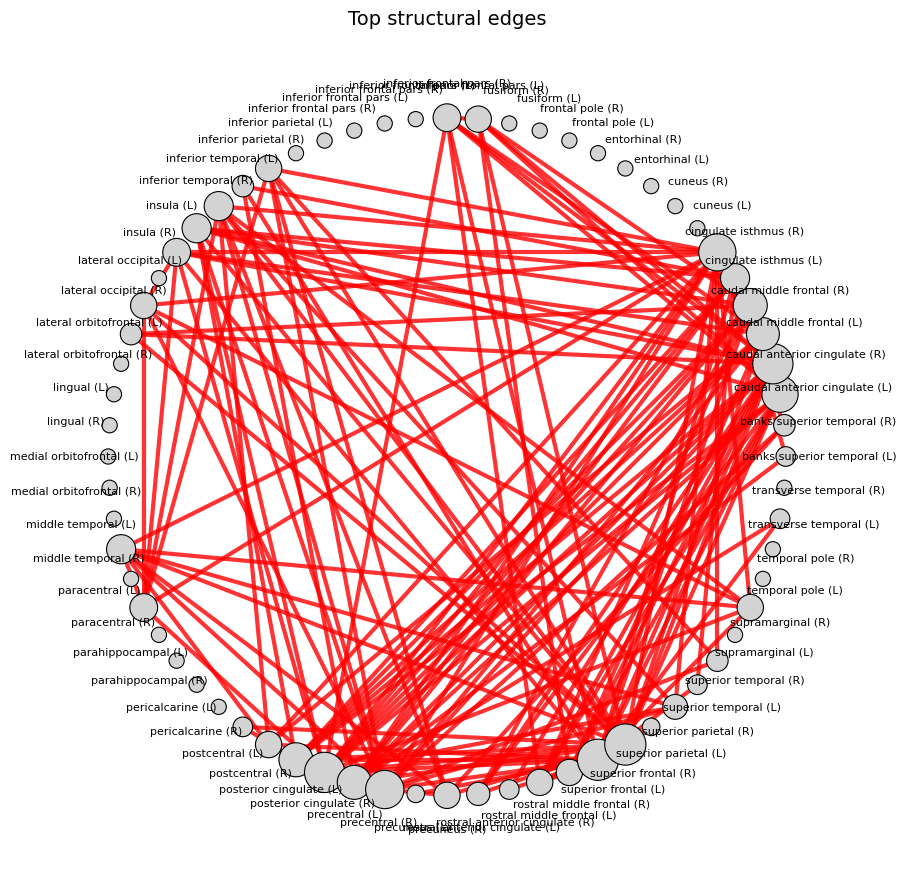

In [4]:
plot_edges(
    selected[selected["in_struct"]],
    pos=shared_pos,
    title="Top structural edges",
    mode="struct",
    save_path=str(figure_dir / 'top_structural.png')
)

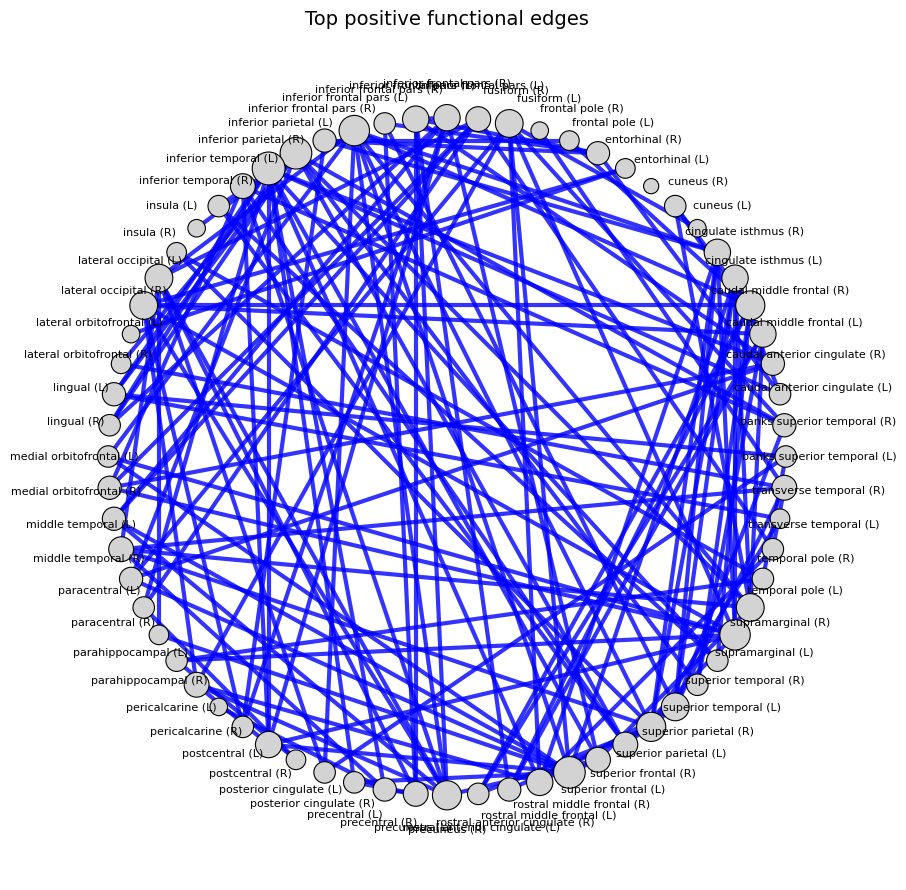

In [5]:
plot_edges(
    selected[selected["in_func_pos"]],
    pos=shared_pos,
    title="Top positive functional edges",
    mode="func_pos",
    save_path=str(figure_dir / 'top_positive_functional.png')
)

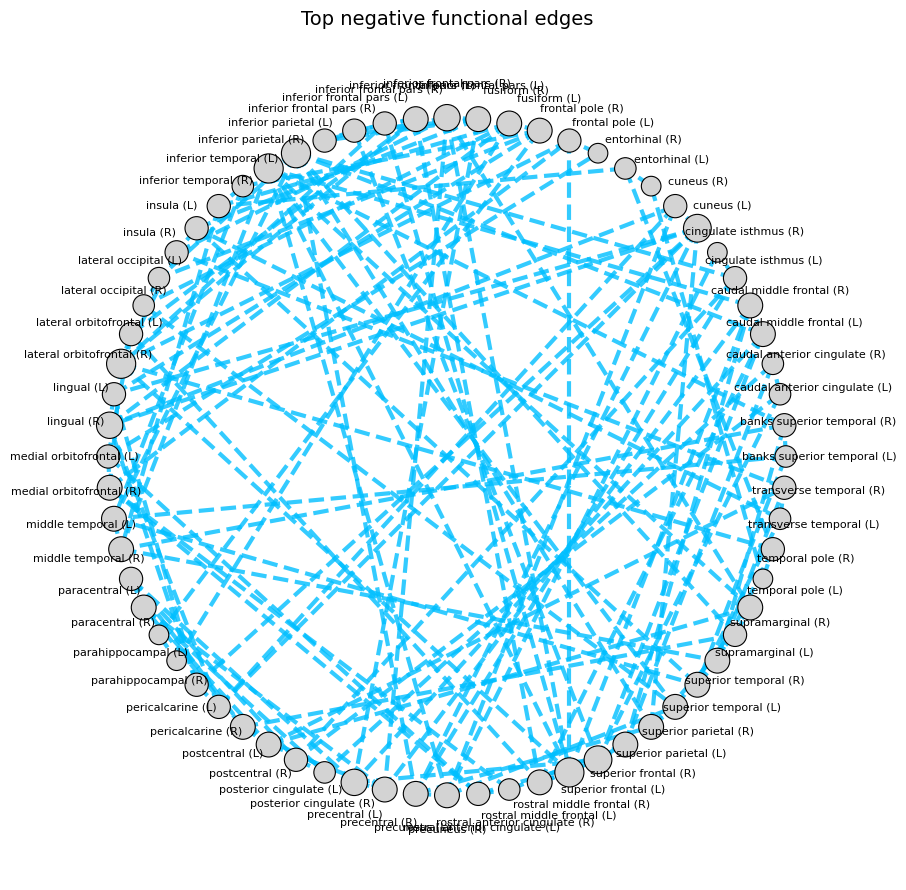

In [6]:
plot_edges(
    selected[selected["in_func_neg"]],
    pos=shared_pos,
    title="Top negative functional edges",
    mode="func_neg",
    save_path=str(figure_dir / 'top_negative_functional.png')
)

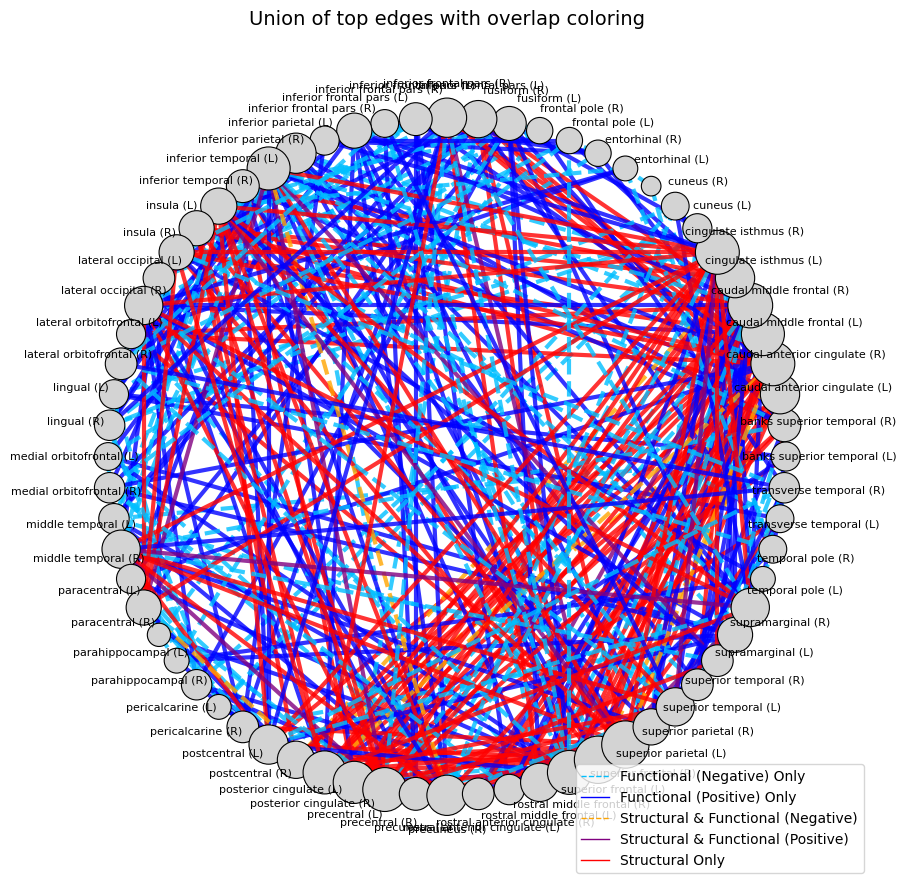

In [7]:
plot_edges(
    selected,
    pos=shared_pos,
    title="Union of top edges with overlap coloring",
    mode="category",
    save_path=str(figure_dir / 'overlap_categories.png')
)

The top 100 structural edges involve 33 unique brain regions.


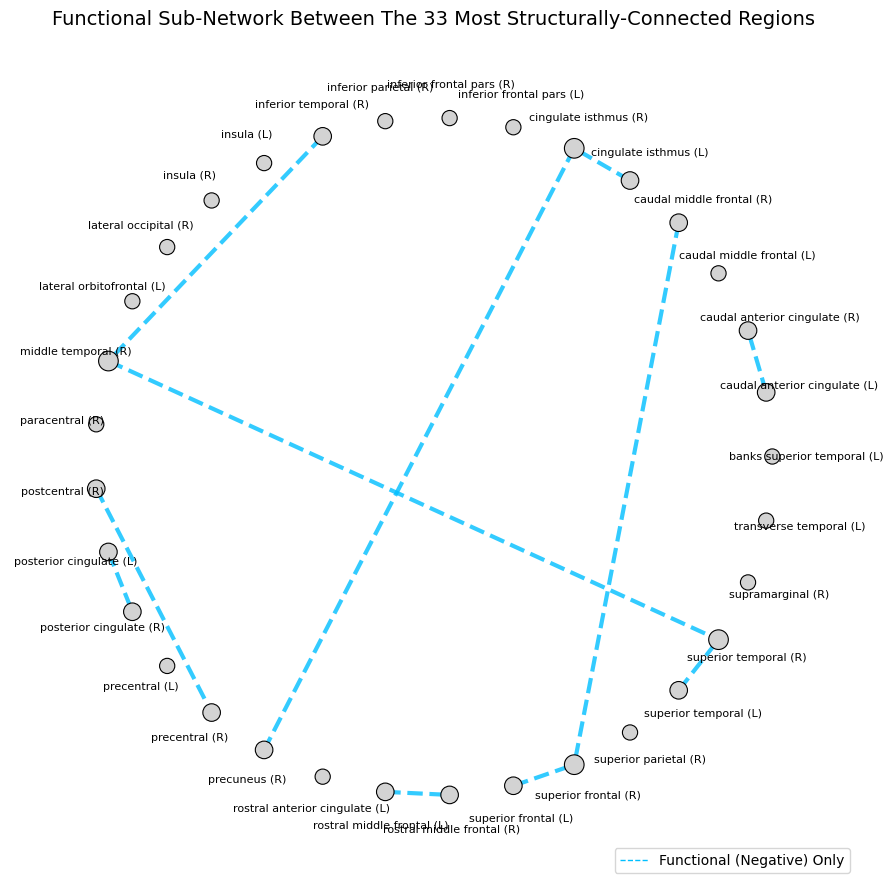


Among the 33 regions with the strongest structural connections:
- We found 0 strong positive functional connections (f > 0.108).
- We found 11 strong negative functional connections (f < -0.181).


In [8]:
# 1. Get the top 100 strongest structural edges
top_100_struct_edges = edges[edges['s'] > 0].nlargest(100, 's').copy()

# 2. Identify the unique nodes from this structural backbone
struct_backbone_nodes = sorted(set(top_100_struct_edges['i']).union(set(top_100_struct_edges['j'])))
print(f"The top 100 structural edges involve {len(struct_backbone_nodes)} unique brain regions.")

# 3. Filter the full edge table to get all connections between these specific nodes
subgraph_edges = edges[edges['i'].isin(struct_backbone_nodes) & edges['j'].isin(struct_backbone_nodes)].copy()

# 4. Define what constitutes a 'strong' functional connection using the previous thresholds
func_pos_threshold = 0.108
func_neg_threshold = -0.181
subgraph_edges['is_func_pos'] = subgraph_edges['f'] > func_pos_threshold
subgraph_edges['is_func_neg'] = subgraph_edges['f'] < func_neg_threshold

# 5. Filter for only the strong functional connections within this subgraph
plot_df = subgraph_edges[subgraph_edges['is_func_pos'] | subgraph_edges['is_func_neg']].copy()

# 6. Categorize these functional edges for plotting
def label_functional_subgraph(row):
    if row['is_func_pos']:
        return "func_pos_only"
    elif row['is_func_neg']:
        return "func_neg_only"
    return "other"

plot_df['category'] = plot_df.apply(label_functional_subgraph, axis=1)

# 7. Build the layout and plot
layout = build_circular_layout(struct_backbone_nodes)
plot_edges(
    plot_df,
    pos=layout,
    title=f"Functional Sub-Network Between The {len(struct_backbone_nodes)} Most Structurally-Connected Regions",
    mode="category"
)

# Print a summary of the functional connections found
num_pos = len(plot_df[plot_df['category'] == 'func_pos_only'])
num_neg = len(plot_df[plot_df['category'] == 'func_neg_only'])

print(f"\nAmong the {len(struct_backbone_nodes)} regions with the strongest structural connections:")
print(f"- We found {num_pos} strong positive functional connections (f > {func_pos_threshold}).")
print(f"- We found {num_neg} strong negative functional connections (f < {func_neg_threshold}).")

In [9]:
print(S)

                                       banks_superior_temporal_sulcus_left  \
banks_superior_temporal_sulcus_left                               0.000000   
caudal_anterior_cingulate_cortex_left                             0.000000   
caudal_middle_frontal_gyrus_left                                  0.189481   
cuneus_left                                                       0.020315   
entorhinal_cortex_left                                            0.000000   
...                                                                    ...   
supramarginal_gyrus_right                                         0.051313   
frontal_pole_right                                                0.000000   
temporal_pole_right                                               0.000000   
transverse_temporal_gyrus_right                                   0.000000   
insula_right                                                      0.025721   

                                       caudal_anterior_cingulat

Out of 100 random structural edges:
- There are 64 unique brain regions involved in this sample.
- 95 are structural only (no strong functional connection).
- 0 also have a strong positive functional connection (f > 0.108).
- 5 also have a strong negative functional connection (f < -0.181).


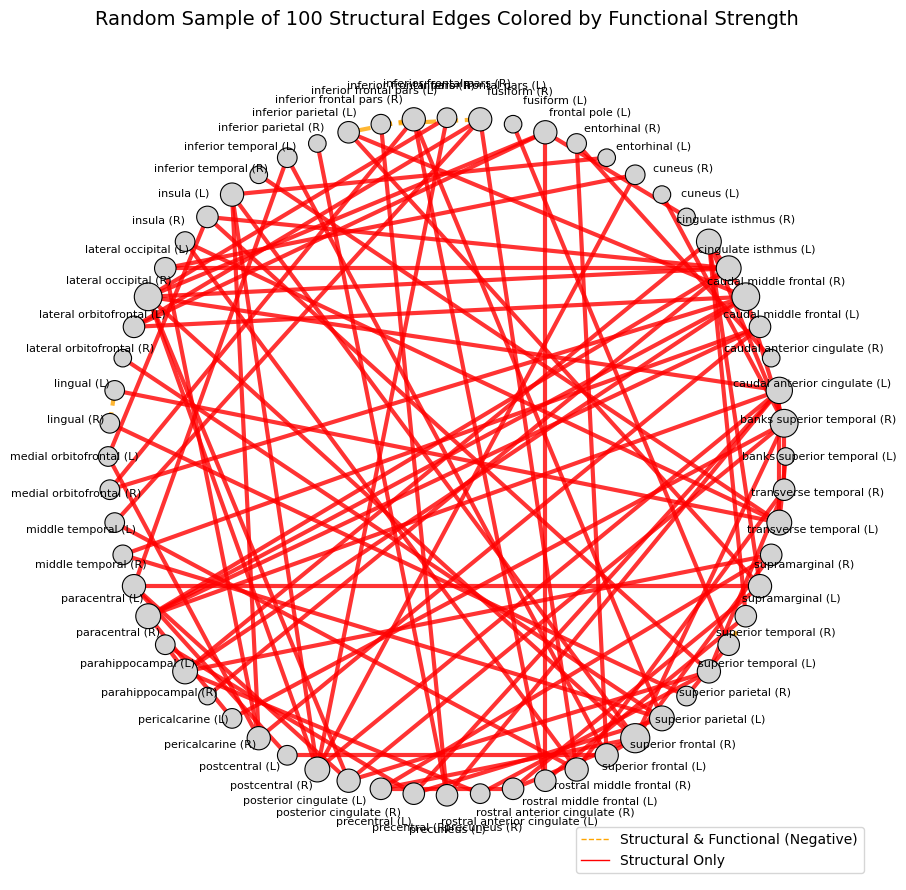

In [10]:
# 1. Take a random sample of 100 structural edges from the full edge table
# This ensures we have both structural (s) and functional (f) values from the start.
all_struct_edges = edges[edges['s'] > 0].copy()
random_struct_sample = all_struct_edges.sample(100, random_state=42) 

# 2. Identify the unique nodes from this sample for layout purposes
nodes_from_sample = sorted(set(random_struct_sample['i']).union(set(random_struct_sample['j'])))

# 3. Define thresholds and categorize the sampled edges
func_pos_threshold = 0.108
func_neg_threshold = -0.181

def label_random_struct_sample(row):
    if row['f'] > func_pos_threshold:
        return "struct_and_func_pos"
    elif row['f'] < func_neg_threshold:
        return "struct_and_func_neg"
    return "struct_only"

# We use the random sample directly as our plot_df
plot_df = random_struct_sample.copy()
plot_df['category'] = plot_df.apply(label_random_struct_sample, axis=1)

# 4. Print a summary of the overlap
struct_and_pos = len(plot_df[plot_df['category'] == 'struct_and_func_pos'])
struct_and_neg = len(plot_df[plot_df['category'] == 'struct_and_func_neg'])
struct_only = len(plot_df[plot_df['category'] == 'struct_only'])


print(f"Out of 100 random structural edges:")
print(f"- There are {len(nodes_from_sample)} unique brain regions involved in this sample.")
print(f"- {struct_only} are structural only (no strong functional connection).")
print(f"- {struct_and_pos} also have a strong positive functional connection (f > {func_pos_threshold}).")
print(f"- {struct_and_neg} also have a strong negative functional connection (f < {func_neg_threshold}).")

# 5. Build the layout and plot
layout = build_circular_layout(nodes_from_sample)
plot_edges(
    plot_df,
    pos=layout,
    title="Random Sample of 100 Structural Edges Colored by Functional Strength",
    mode="category"
)